In [ ]:
import eval_common as _ec
_ec.set_axis("mechanism")
AXIS = _ec.AXIS
print("AXIS =", AXIS, "| categories:", _ec.MECH_ORDER)

AXIS = mechanism | categories: ['Reliability', 'Bias & Fairness', 'Privacy, Confidentiality & Infringement', 'Security & Misuse', 'Autonomous Actions', 'Governance, Oversight & Explainability']


In [ ]:
from pathlib import Path
import warnings, gc
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.linalg import eigvals
from sklearn.metrics import mean_absolute_error, mean_squared_error

RANDOM_SEED = 42
TRAPZ = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
ORIGIN_FREQ = "M"

DATE_COL   = "date"
OUTPUT_DIR = _ec.OUTPUT_DIR
MECH_ORDER = _ec.MECH_ORDER
DIMENSION  = len(MECH_ORDER)
REFERENCE  = _ec.REFERENCE_CATEGORY
NON_REF    = MECH_ORDER[:-1] 

BETA_GRID            = [1/30, 1/60, 1/90]     # excitation decay (per day)
RIDGE_GRID           = [0.1, 1.0]             # ridge on branching matrix K
RHO_MAX_GRID         = [0.90]           # spectral-radius cap (< 1)
SPLINE_DF_GRID       = [3, 4]              # baseline spline flexibility
SPLINE_PENALTY_GRID  = [1.0]            # 2nd-difference roughness penalty
SMOOTHING_GRID       = [0.0, 0.10, 0.20]      # shrink share toward historical mix

N_STARTS_TUNE  = 1
N_STARTS_FINAL = 3
N_SIMS_TUNE    = 80
N_SIMS_FINAL   = 400
YEAR_DAYS      = 365.25

In [ ]:
df = _ec.load_incidents()
df["mech7"] = df["mechanism"]
counts = _ec.build_counts(df)
full_months = pd.period_range(counts.index.min(), counts.index.max(), freq="M")
evaluate = _ec.evaluate
mlog = _ec.mlog
print(counts.shape, counts.index[0], "->", counts.index[-1])
print(df["mech7"].value_counts().reindex(MECH_ORDER))

(127, 6) 2016-01 -> 2026-07
mech7
Reliability                                218
Bias & Fairness                            168
Privacy, Confidentiality & Infringement    223
Security & Misuse                          664
Autonomous Actions                         222
Governance, Oversight & Explainability      82
Name: count, dtype: int64


In [ ]:
def dates_to_events(data, origin):
    """Return (event_times_in_days, mark_indices) sorted by time."""
    x = data.sort_values([DATE_COL, "incident_id"]).copy() \
        if "incident_id" in data.columns else data.sort_values(DATE_COL).copy()
    times = (x[DATE_COL] - origin).dt.total_seconds().to_numpy() / 86400.0
    order = np.argsort(times, kind="mergesort")
    times = times[order]
    marks = x["mechanism"].map({m: i for i, m in enumerate(MECH_ORDER)}).to_numpy()[order]
    # jitter ties
    for i in range(1, len(times)):
        if times[i] <= times[i-1]:
            times[i] = times[i-1] + 1e-5
    return times.astype(float), marks.astype(int)


ORIGIN = counts.index.min().to_timestamp()
T_END  = float((counts.index.max().to_timestamp() + pd.Timedelta(days=30) - ORIGIN).days)


def spline_basis(t_days, knots):
    """Truncated-power natural cubic spline basis. Returns [n, df] design matrix
    including an intercept column. `knots` are interior knot positions in days."""
    t = np.asarray(t_days, float).reshape(-1, 1)
    cols = [np.ones_like(t), t] 
    K = np.asarray(knots, float)
    if len(K) >= 2:
        dK = (K[-1] - K)
        def tp(x, k):
            d = np.clip(x - k, 0, None)
            return d**3
        last = K[-1]
        denom = max(last - K[0], 1e-9)
        for k in K[:-2]:
            basis = (tp(t, k) - tp(t, last)) / denom
            cols.append(basis)
    return np.hstack(cols)


def make_knots(train_horizon, df_spline):
    """Interior knots at even quantiles of [0, train_horizon]."""
    n_interior = max(df_spline, 2)
    qs = np.linspace(0.0, 1.0, n_interior)
    return qs * train_horizon


def second_diff_penalty(n_params):
    """Roughness penalty matrix on the spline coefficients (2nd differences)."""
    if n_params < 3:
        return np.zeros((n_params, n_params))
    D = np.zeros((n_params - 2, n_params))
    for i in range(n_params - 2):
        D[i, i] = 1.0; D[i, i+1] = -2.0; D[i, i+2] = 1.0
    return D.T @ D


In [ ]:
def unpack(theta, dimension, n_spline):
    """theta = [ baseline_coeffs (D x n_spline) , K_raw (D x D) ]."""
    n_b = dimension * n_spline
    B = theta[:n_b].reshape(dimension, n_spline)
    K = theta[n_b:].reshape(dimension, dimension)
    return B, K


def log_baseline(t_days, B, basis_knots):
    t_clamped = np.clip(t_days, 0.0, basis_knots[-1])
    design = spline_basis(t_clamped, basis_knots)
    return design @ B.T


def compositional_hawkes_nll(theta, times, marks, horizon, beta, knots,
                             ridge, spline_penalty, rho_max):
    """Penalised negative log-likelihood of the marked Hawkes with a spline
    log-baseline. Excitation uses an exponential kernel and a D x D matrix K.
    Stationarity enforced by a soft penalty when spectral radius > rho_max."""
    n_spline = spline_basis(np.array([0.0]), knots).shape[1]
    B, K_raw = unpack(theta, DIMENSION, n_spline)
    K = np.clip(K_raw, 0, None) 

    logmu_events = log_baseline(times, B, knots)
    mu_events = np.exp(np.clip(logmu_events, -30, 30))

    state = np.zeros(DIMENSION)
    last_t = 0.0
    loglik = 0.0
    for idx in range(len(times)):
        t = times[idx]; c = marks[idx]
        state *= np.exp(-beta * (t - last_t))
        intensity_c = mu_events[idx, c] + beta * (K[c] @ state)
        loglik += np.log(max(intensity_c, 1e-300))
        state[c] += 1.0
        last_t = t

    grid = np.linspace(0.0, horizon, 150)
    logmu_grid = log_baseline(grid, B, knots)
    mu_grid = np.exp(np.clip(logmu_grid, -30, 30))
    baseline_integral = TRAPZ(mu_grid.sum(axis=1), grid)
    exc_integral = 0.0
    for idx in range(len(times)):
        t = times[idx]; c = marks[idx]
        exc_integral += K[:, c].sum() * (1.0 - np.exp(-beta * (horizon - t)))
    compensator = baseline_integral + exc_integral

    nll = -(loglik - compensator)

    nll += ridge * np.sum(K**2)
    P = second_diff_penalty(n_spline)
    nll += spline_penalty * np.sum([B[i] @ P @ B[i] for i in range(DIMENSION)])
    sr = np.max(np.abs(eigvals(K))) if DIMENSION > 1 else float(K[0, 0])
    if sr > rho_max:
        nll += 1e4 * (sr - rho_max)**2
    return nll


def fit_compositional_hawkes(times, marks, horizon, beta, df_spline,
                             ridge, spline_penalty, rho_max, n_starts, max_iter=100):
    knots = make_knots(horizon, df_spline)
    n_spline = spline_basis(np.array([0.0]), knots).shape[1]
    rng = np.random.default_rng(RANDOM_SEED + int(beta*1e5) + df_spline)

    rates = np.bincount(marks, minlength=DIMENSION) / max(horizon, 1.0)
    logr = np.log(np.clip(rates, 1e-6, None))

    best = None
    for _ in range(n_starts):
        B0 = np.zeros((DIMENSION, n_spline)); B0[:, 0] = logr
        B0 += rng.normal(0, 0.1, B0.shape)
        K0 = rng.uniform(0.0, 0.1, (DIMENSION, DIMENSION))
        theta0 = np.concatenate([B0.ravel(), K0.ravel()])
        try:
            res = minimize(
                compositional_hawkes_nll, theta0,
                args=(times, marks, horizon, beta, knots, ridge, spline_penalty, rho_max),
                method="L-BFGS-B", options={"maxiter": 1000, "maxfun": 5000})
            if best is None or res.fun < best["objective"]:
                B, K_raw = unpack(res.x, DIMENSION, n_spline)
                K = np.clip(K_raw, 0, None)
                sr = float(np.max(np.abs(eigvals(K)))) if DIMENSION > 1 else float(K[0,0])
                best = {"B": B, "K": K, "beta": beta, "knots": knots,
                        "objective": float(res.fun), "success": bool(res.success),
                        "message": str(res.message), "spectral_radius": sr,
                        "training_horizon": horizon}
        except Exception as e:
            continue
    if best is None:
        raise RuntimeError("compositional Hawkes fit failed at all starts")
    return best


In [ ]:
def historical_mark_shares(train_marks, pseudocount=0.5):
    c = np.bincount(train_marks, minlength=DIMENSION).astype(float) + pseudocount
    return c / c.sum()


def _decayed_state_at(fit, hist_times, hist_marks, t_eval):
    """Per-category accumulated excitation state at time t_eval:
    state_j = sum over past category-j events of exp(-beta (t_eval - t_k))."""
    beta = fit["beta"]
    state = np.zeros(DIMENSION)
    mask = hist_times < t_eval
    if mask.any():
        dt = t_eval - hist_times[mask]
        contrib = np.exp(-beta * dt)
        for j_mark, c in zip(hist_marks[mask], contrib):
            state[int(j_mark)] += c
    return state


def forecast_fold(fit, train_times, train_marks, fold, n_sims, smoothing):
    """Analytic compositional forecast. Integrates each category's fitted
    intensity over each future month to get expected counts, then normalises to
    shares. `n_sims` is accepted for interface compatibility but unused.

    Expected count for category i over month [a, b]:
        E[y_i] = integral_a^b lambda_i(u) du
               = integral_a^b mu_i(u) du                          (baseline part)
               + sum_j K_ij * sum_{t_k^(j) < b} [ decay integral ] (excitation part)

    For the exponential kernel g(s) = beta * e^{-beta s}, the integral of the
    excitation contribution of one past event at t_k over [a, b] is
        K_ij * ( e^{-beta (max(a,t_k) - t_k)} - e^{-beta (b - t_k)} ),
    i.e. K_ij times the decayed mass released across the interval.
    """
    B, K, beta, knots = fit["B"], fit["K"], fit["beta"], fit["knots"]
    yr, half = fold
    fstart, fend = _ec.fold_bounds(yr, half)
    months = pd.period_range(fstart, fend, freq="M")
    prior = historical_mark_shares(train_marks)

    rows = []
    for month in months:
        a = float((month.to_timestamp() - ORIGIN).days)
        b = float(((month + 1).to_timestamp() - ORIGIN).days)

        grid = np.linspace(a, b, 40)
        logmu = log_baseline(grid, B, knots)
        mu = np.exp(np.clip(logmu, -30, 30))
        baseline_counts = TRAPZ(mu, grid, axis=0) 

        exc_counts = np.zeros(DIMENSION)
        past = train_times < b
        if past.any():
            tk = train_times[past]
            ck = train_marks[past]
            lower = np.maximum(a, tk)
            released = np.exp(-beta * (lower - tk)) - np.exp(-beta * (b - tk))  
            released = np.clip(released, 0.0, None)
            trig = np.zeros(DIMENSION)
            for j_mark, r in zip(ck, released):
                trig[int(j_mark)] += r
            exc_counts = K @ trig 

        expected = baseline_counts + exc_counts
        expected = np.clip(expected, 1e-12, None)
        raw = expected / expected.sum()

        shares = (1.0 - smoothing) * raw + smoothing * prior
        shares = np.clip(shares, 1e-12, None)
        shares /= shares.sum()

        for k, cat in enumerate(MECH_ORDER):
            rows.append({"month_period": month, "category": cat,
                         "predicted_share": float(shares[k])})
    return pd.DataFrame(rows)

def attach_actuals(forecast, actual_counts):
    a = (actual_counts.rename_axis("month_period").reset_index()
         .melt(id_vars="month_period", var_name="category", value_name="actual_count"))
    a["tot"] = a.groupby("month_period")["actual_count"].transform("sum")
    a["actual_share"] = a["actual_count"] / a["tot"].clip(lower=1e-12)
    f = forecast.copy()
    a["month_period"] = a["month_period"].astype(str)
    f["month_period"] = f["month_period"].astype(str)
    return f.merge(a[["month_period","category","actual_count","actual_share"]],
                   on=["month_period","category"], how="inner")


def score_forecast(scored):
    mae = mean_absolute_error(scored["actual_share"], scored["predicted_share"])
    rmse = mean_squared_error(scored["actual_share"], scored["predicted_share"])**0.5
    ls = (scored.groupby("month_period")
          .apply(lambda g: mlog(g["actual_count"], g["predicted_share"]),
                 include_groups=False).mean())
    return {"mae": float(mae), "rmse": float(rmse), "log_score": float(ls)}

In [ ]:
def prepare_events(data):
    return dates_to_events(data, ORIGIN)


def tune_compositional_hawkes(outer_train_df, outer_fold):
    val_yr, val_half = _ec.prev_fold(*outer_fold)
    vstart, vend = _ec.fold_bounds(val_yr, val_half)
    inner_df = outer_train_df[outer_train_df["month_period"] < vstart].copy()
    val_counts = counts[(counts.index >= vstart) & (counts.index <= vend)].copy()
    if inner_df.empty or val_counts.empty:
        raise RuntimeError(f"No inner validation fold for {_ec.fold_label(*outer_fold)}.")

    inner_t, inner_m = prepare_events(inner_df)
    inner_h = float((vstart.to_timestamp() - ORIGIN).days)

    rows = []
    total = (len(BETA_GRID)*len(RIDGE_GRID)*len(RHO_MAX_GRID)
             *len(SPLINE_DF_GRID)*len(SPLINE_PENALTY_GRID))
    n = 0
    for beta in BETA_GRID:
      for ridge in RIDGE_GRID:
        for rho_max in RHO_MAX_GRID:
          for df_s in SPLINE_DF_GRID:
            for sp in SPLINE_PENALTY_GRID:
                n += 1
                print(f"  fit {n}/{total} beta={beta:.4f} df={df_s} FITTING", flush=True)
                try:
                    fit = fit_compositional_hawkes(
                        inner_t, inner_m, inner_h, beta, df_s, ridge, sp,
                        rho_max, N_STARTS_TUNE)
                    print(f"    fit done sr={fit['spectral_radius']:.3f}", flush=True)
                    for sm in SMOOTHING_GRID:
                        print(f"    forecasting sm={sm}", flush=True)
                        fc = forecast_fold(fit, inner_t, inner_m,
                                           (val_yr, val_half), N_SIMS_TUNE, sm)
                        print(f"      fc done rows={len(fc)}", flush=True)
                        sc = attach_actuals(fc, val_counts)
                        mt = score_forecast(sc)
                        rows.append({
                            "outer_fold": _ec.fold_label(*outer_fold),
                            "validation_fold": _ec.fold_label(val_yr, val_half),
                            "beta": beta, "half_life_days": float(np.log(2)/beta),
                            "ridge": ridge, "rho_max": rho_max,
                            "spline_df": df_s, "spline_penalty": sp, "smoothing": sm,
                            "spectral_radius": fit["spectral_radius"],
                            "converged": fit["success"],
                            "validation_mae": mt["mae"], "validation_rmse": mt["rmse"],
                            "validation_log_score": mt["log_score"], "status": "success"})
                except Exception as e:
                    rows.append({
                        "outer_fold": _ec.fold_label(*outer_fold),
                        "validation_fold": _ec.fold_label(val_yr, val_half),
                        "beta": beta, "half_life_days": float(np.log(2)/beta),
                        "ridge": ridge, "rho_max": rho_max,
                        "spline_df": df_s, "spline_penalty": sp, "smoothing": np.nan,
                        "spectral_radius": np.nan, "converged": False,
                        "validation_mae": np.nan, "validation_rmse": np.nan,
                        "validation_log_score": np.nan,
                        "status": f"{type(e).__name__}: {e}"})
                finally:
                    gc.collect()
    print()
    results = pd.DataFrame(rows)
    ok = results[results["status"]=="success"].dropna(
        subset=["validation_log_score","validation_mae","validation_rmse"])
    if ok.empty:
        display(results)
        raise RuntimeError(f"All candidates failed for {_ec.fold_label(*outer_fold)}.")
    best = ok.sort_values(
        ["converged","validation_log_score","validation_mae","validation_rmse","spectral_radius"],
        ascending=[False, False, True, True, True]).iloc[0]
    selected = {"beta": float(best["beta"]), "ridge": float(best["ridge"]),
                "rho_max": float(best["rho_max"]), "spline_df": int(best["spline_df"]),
                "spline_penalty": float(best["spline_penalty"]),
                "smoothing": float(best["smoothing"])}
    return selected, results


In [ ]:
MODEL = "compositional_hawkes"
prediction_frames, tuning_frames, selected_rows, diag_rows = [], [], [], []
fold_fits = {}

for (yr, half) in _ec.TEST_FOLDS:
    fold = (yr, half); fold_str = _ec.fold_label(yr, half)
    fstart, fend = _ec.fold_bounds(yr, half)
    print(f"\nTraining before {fold_str}; forecasting {fold_str}")

    outer_train_df = df[df["month_period"] < fstart].copy()
    test_counts = counts[(counts.index >= fstart) & (counts.index <= fend)].copy()
    if outer_train_df.empty or test_counts.empty:
        continue
    try:
        selected, fold_tuning = tune_compositional_hawkes(outer_train_df, fold)
        tuning_frames.append(fold_tuning)
        print("Selected:", selected)

        tr_t, tr_m = prepare_events(outer_train_df)
        tr_h = float((fstart.to_timestamp() - ORIGIN).days)
        fit = fit_compositional_hawkes(
            tr_t, tr_m, tr_h, selected["beta"], selected["spline_df"],
            selected["ridge"], selected["spline_penalty"], selected["rho_max"],
            N_STARTS_FINAL)
        fc = forecast_fold(fit, tr_t, tr_m, fold, N_SIMS_FINAL, selected["smoothing"])
    except Exception as e:
        print(f"{fold_str} failed: {type(e).__name__}: {e}")
        continue

    fold_fits[fold_str] = fit
    selected_rows.append({"fold": fold_str, **selected,
                          "half_life_days": np.log(2)/selected["beta"],
                          "spectral_radius": fit["spectral_radius"],
                          "converged": fit["success"]})
    diag_rows.append({"fold": fold_str, "objective": fit["objective"],
                      "spectral_radius": fit["spectral_radius"],
                      "success": fit["success"], "message": fit["message"]})

    sc = attach_actuals(fc, test_counts)
    sc["model"] = MODEL
    sc["fold"] = fold_str
    prediction_frames.append(sc[["model","fold","month_period","category",
                                 "actual_count","actual_share","predicted_share"]])

if not prediction_frames:
    raise RuntimeError("No compositional Hawkes forecasts were created.")

predictions = pd.concat(prediction_frames, ignore_index=True)
predictions["month_period"] = predictions["month_period"].astype(str)
tuning_results = pd.concat(tuning_frames, ignore_index=True)
selected_models = pd.DataFrame(selected_rows)
diagnostics = pd.DataFrame(diag_rows)



Training before 2020-H1; forecasting 2020-H1
  fit 1/12 beta=0.0333 df=3 FITTING
    fit done sr=0.903
    forecasting sm=0.0
      fc done rows=36
    forecasting sm=0.1
      fc done rows=36
    forecasting sm=0.2
      fc done rows=36
  fit 2/12 beta=0.0333 df=4 FITTING
    fit done sr=0.887
    forecasting sm=0.0
      fc done rows=36
    forecasting sm=0.1
      fc done rows=36
    forecasting sm=0.2
      fc done rows=36
  fit 3/12 beta=0.0333 df=3 FITTING
    fit done sr=0.520
    forecasting sm=0.0
      fc done rows=36
    forecasting sm=0.1
      fc done rows=36
    forecasting sm=0.2
      fc done rows=36
  fit 4/12 beta=0.0333 df=4 FITTING
    fit done sr=0.865
    forecasting sm=0.0
      fc done rows=36
    forecasting sm=0.1
      fc done rows=36
    forecasting sm=0.2
      fc done rows=36
  fit 5/12 beta=0.0167 df=3 FITTING
    fit done sr=0.855
    forecasting sm=0.0
      fc done rows=36
    forecasting sm=0.1
      fc done rows=36
    forecasting sm=0.2
      fc do

In [ ]:
share_sums = predictions.groupby(["fold","month_period"])["predicted_share"].sum()
print("share-sum range:", share_sums.min(), "to", share_sums.max())

overall, by_fold = evaluate(predictions)
print("Overall compositional Hawkes performance"); display(overall)
print("Performance by fold"); display(by_fold)
print("Selected parameters by fold"); display(selected_models)
print("Fit diagnostics"); display(diagnostics)


share-sum range: 0.9999999999999998 to 1.0000000000000002
Overall compositional Hawkes performance


,model,mae,rmse,mean_log_score_per_incident
0,compositional_hawkes,0.096454,0.129095,-1.653102


Performance by fold


,model,fold,mae,rmse
0,compositional_hawkes,2020-H1,0.158860,0.202441
1,compositional_hawkes,2020-H2,0.112550,0.140140
2,compositional_hawkes,2021-H1,0.119427,0.141647
3,compositional_hawkes,2021-H2,0.114685,0.132431
4,compositional_hawkes,2022-H1,0.079348,0.095657
5,compositional_hawkes,2022-H2,0.102905,0.130028
6,compositional_hawkes,2023-H1,0.110207,0.152605
7,compositional_hawkes,2023-H2,0.108923,0.144670
8,compositional_hawkes,2024-H1,0.095569,0.125484
9,compositional_hawkes,2024-H2,0.100003,0.140379


Selected parameters by fold


,fold,beta,ridge,rho_max,spline_df,spline_penalty,smoothing,half_life_days,spectral_radius,converged
0,2020-H1,0.011111,0.1,0.9,3,1.0,0.2,62.383246,0.866045,True
1,2020-H2,0.033333,0.1,0.9,4,1.0,0.0,20.794415,0.470860,False
2,2021-H1,0.016667,0.1,0.9,3,1.0,0.0,41.588831,0.854939,True
3,2021-H2,0.011111,1.0,0.9,4,1.0,0.0,62.383246,0.755662,True
4,2022-H1,0.016667,1.0,0.9,4,1.0,0.0,41.588831,0.673278,True
5,2022-H2,0.016667,1.0,0.9,3,1.0,0.2,41.588831,0.906547,True
6,2023-H1,0.033333,0.1,0.9,3,1.0,0.0,20.794415,0.912227,True
7,2023-H2,0.016667,0.1,0.9,3,1.0,0.0,41.588831,0.825202,True
8,2024-H1,0.016667,1.0,0.9,3,1.0,0.0,41.588831,0.911469,True
9,2024-H2,0.033333,1.0,0.9,4,1.0,0.0,20.794415,0.893763,True


Fit diagnostics


,fold,objective,spectral_radius,success,message
0,2020-H1,959.472118,0.866045,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
1,2020-H2,1244.456497,0.470860,False,ABNORMAL:
2,2021-H1,1346.880811,0.854939,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
3,2021-H2,1546.654226,0.755662,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
4,2022-H1,1715.970003,0.673278,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
5,2022-H2,1871.804065,0.906547,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
6,2023-H1,2109.579571,0.912227,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
7,2023-H2,2451.463022,0.825202,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
8,2024-H1,2686.566601,0.911469,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
9,2024-H2,3108.245155,0.893763,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...


Spectral radius: 0.3183
Branching matrix (expected offspring by trigger->excited):


trigger_type,Reliability,Bias & Fairness,"Privacy, Confidentiality & Infringement",Security & Misuse,Autonomous Actions,"Governance, Oversight & Explainability"
excited_type,,,,,,
Reliability,0.088,0.031,0.015,0.029,0.096,0.005
Bias & Fairness,0.051,0.008,0.079,0.096,0.085,0.079
"Privacy, Confidentiality & Infringement",0.018,0.031,0.095,0.059,0.091,0.058
Security & Misuse,0.037,0.036,0.031,0.067,0.086,0.074
Autonomous Actions,0.009,0.038,0.026,0.077,0.031,0.097
"Governance, Oversight & Explainability",0.053,0.067,0.078,0.031,0.062,0.013


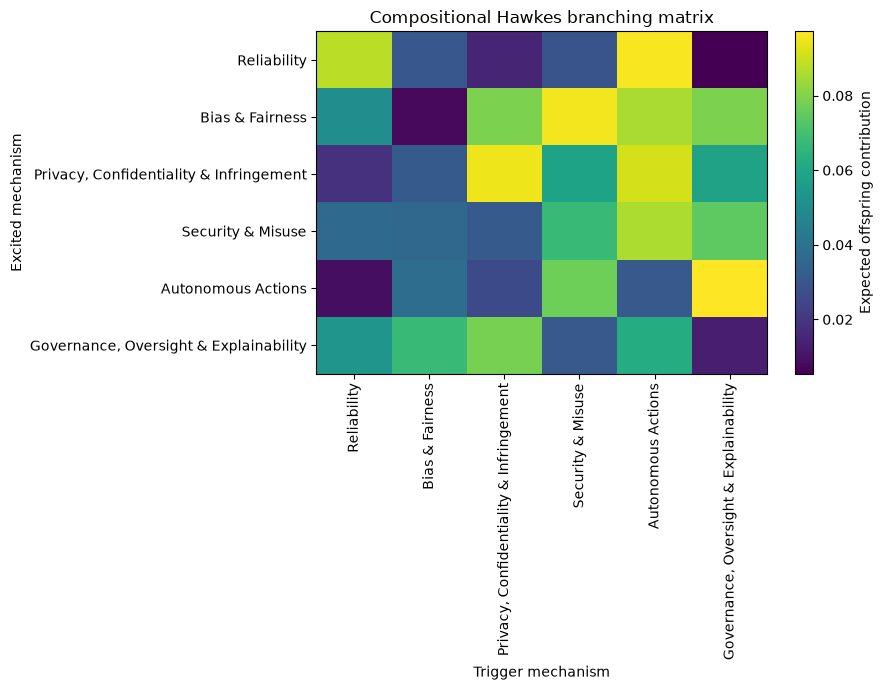

In [ ]:
latest = selected_models.iloc[-1]
full_t, full_m = prepare_events(df)
full_fit = fit_compositional_hawkes(
    full_t, full_m, T_END,
    beta=float(latest["beta"]), df_spline=int(latest["spline_df"]),
    ridge=float(latest["ridge"]), spline_penalty=float(latest["spline_penalty"]),
    rho_max=float(latest["rho_max"]), n_starts=N_STARTS_FINAL)

full_K = pd.DataFrame(full_fit["K"], index=MECH_ORDER, columns=MECH_ORDER)
full_K.index.name = "excited_type"; full_K.columns.name = "trigger_type"
print("Spectral radius:", round(full_fit["spectral_radius"], 4))
print("Branching matrix (expected offspring by trigger->excited):")
display(full_K.round(3))

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(full_K.to_numpy(), aspect="auto")
ax.set_xticks(range(DIMENSION), MECH_ORDER, rotation=90)
ax.set_yticks(range(DIMENSION), MECH_ORDER)
ax.set_xlabel("Trigger mechanism"); ax.set_ylabel("Excited mechanism")
ax.set_title("Compositional Hawkes branching matrix")
fig.colorbar(im, ax=ax, label="Expected offspring contribution")
plt.tight_layout(); plt.show()


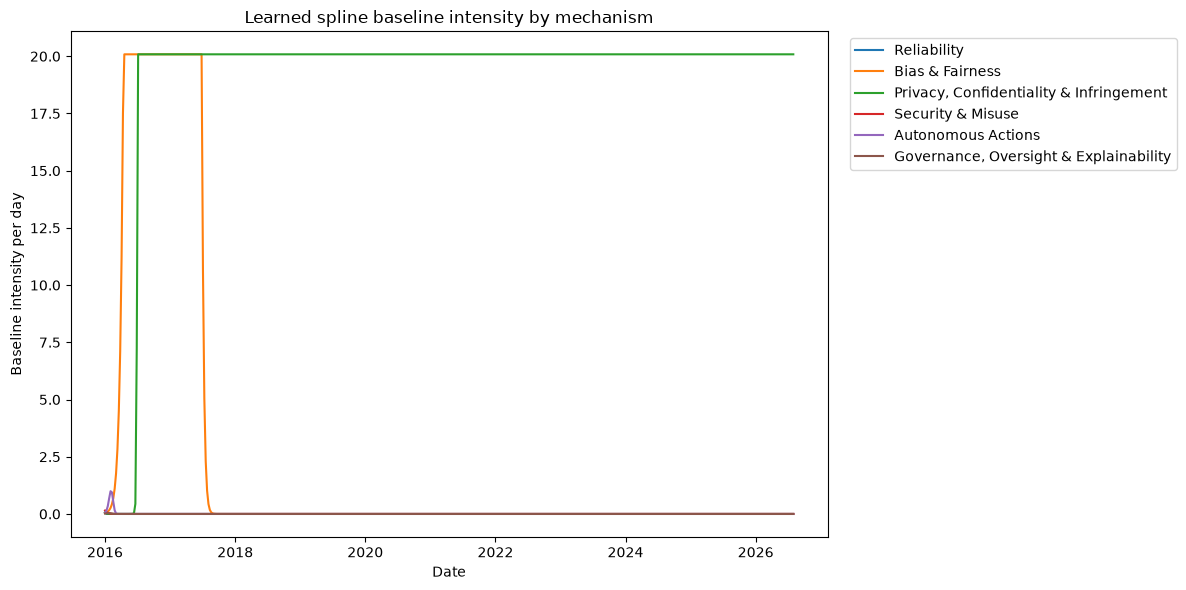

In [ ]:
grid = np.linspace(0.0, T_END, 500)
logmu = log_baseline(grid, full_fit["B"], full_fit["knots"])
mu = np.exp(np.clip(logmu, -12, 3)) 
dates = ORIGIN + pd.to_timedelta(grid, unit="D")

fig, ax = plt.subplots(figsize=(12, 6))
for i, cat in enumerate(MECH_ORDER):
    ax.plot(dates, mu[:, i], label=cat)
ax.set_xlabel("Date"); ax.set_ylabel("Baseline intensity per day")
ax.set_title("Learned spline baseline intensity by mechanism")
ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left")
plt.tight_layout(); plt.show()


In [ ]:
import eval_common as _ec
AXIS, OUT = _ec.AXIS, _ec.OUTPUT_DIR
MODEL = "compositional_hawkes"

_pred = predictions.copy()
if "model" not in _pred.columns: _pred.insert(0, "model", MODEL)
_pred["month_period"] = _pred["month_period"].astype(str)
_pred.to_csv(OUT / f"predictions_{MODEL}_{AXIS}.csv", index=False)

_ov = overall.copy()
if "model" not in _ov.columns: _ov.insert(0, "model", MODEL)
_ov.to_csv(OUT / f"metrics_{MODEL}_overall_{AXIS}.csv", index=False)
by_fold.to_csv(OUT / f"metrics_{MODEL}_byfold_{AXIS}.csv", index=False)
selected_models.to_csv(OUT / f"selected_{MODEL}_{AXIS}.csv", index=False)

_ss = _pred.groupby(["fold","month_period"])["predicted_share"].sum()
print("share-sum range:", round(_ss.min(),6), "to", round(_ss.max(),6))
assert {"model","fold","month_period","category","actual_count","predicted_share"} <= set(_pred.columns)
print("Saved:", f"predictions_{MODEL}_{AXIS}.csv", "+ metrics")


share-sum range: 1.0 to 1.0
Saved: predictions_compositional_hawkes_mechanism.csv + metrics
